In [1]:
%load_ext autoreload    
%autoreload 2
from analysis.analysis_util import *
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
def load_target(target_path, config):
    config.target_name = target_path
    pilmode = "RGB" if len(config.color_mode) == 3 else "L"
    target = torch.tensor(iio.imread(target_path, pilmode=pilmode), dtype=torch.float32, device=config.device)
    if target.max()>1.0:
        target /= 255.0
    config.target = target
    resize_target(config)
    config.target =  config.target.unsqueeze(0)
    if len(config.target.shape) == 3:
        # L -> RGB
        config.target = config.target.unsqueeze(1)
        config.target = config.target.repeat(1, 3, 1, 1)
    else:
        # RGB -> RGB
        config.target = config.target.permute(0,3,1,2)
    return config.target


In [3]:
# path = "../results/bloat-then-min-prune-cxs-only/conditions/bloat-then-min-prune-16-16/run_2733497647036568046/"
path = "../results/test/conditions/test/run_14901248866147111406"

In [4]:
cppns, config = get_cppns_by_batch(path, modulo=1)
set_max_node_id(cppns)

  0%|          | 0/4 [00:00<?, ?it/s]WARNING:root:Unexpected key population_size in config <class 'move_config.MoveConfig'>


100%|██████████| 4/4 [00:00<00:00,  6.09it/s]


Loaded 4 genomes


In [5]:
from copy import deepcopy

cppns_batched = deepcopy(cppns)
cppns_unbatched = deepcopy(cppns)

In [ ]:
from sgd_weights import sgd_weights
from norm import read_norm_data
target = load_target("data/skull.png", config).to(device)
batched_targets = torch.stack([target for _ in range(len(cppns_batched))], dim=1).to(device).squeeze(0)
inputs = load_inputs(path).to(device)
norm = read_norm_data(os.path.join(config.norm_df_path), config.target_path)


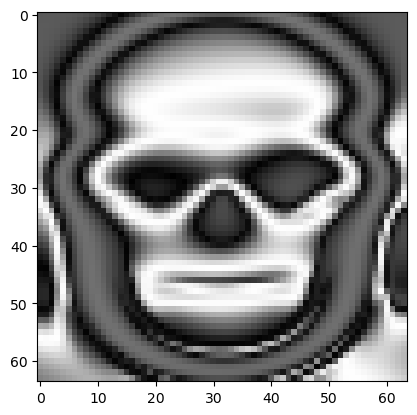

In [7]:
import matplotlib.pyplot as plt
plt.imshow(target[0].permute(1,2,0).cpu().numpy())
plt.show()

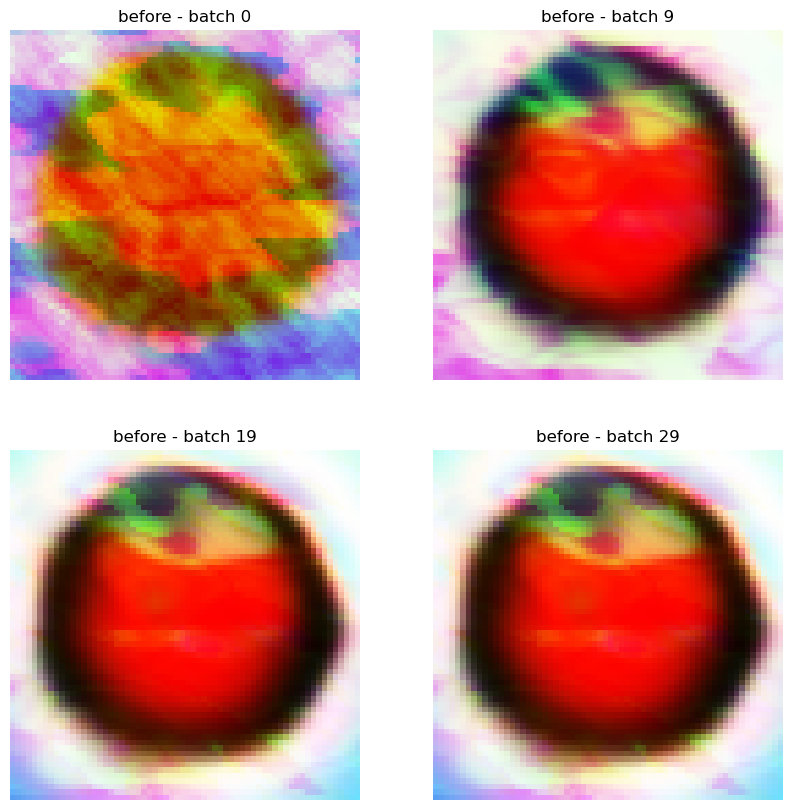

In [8]:
import math
rows = math.ceil(len(cppns_batched)/2)
fig, axs = plt.subplots(rows, 2, figsize=(10, 10))
axs = axs.flatten()
for ax in axs:
    ax.axis("off")
for i, (batch, cppn) in enumerate(cppns_batched.items()):
    cppn = cppn.to(device)
    ax = axs[i]
    ax.imshow(cppn(inputs, channel_first=False).detach().cpu().numpy(), cmap="gray")
    ax.set_title(f"before - batch {batch}")
plt.show()

In [9]:
N_TRIALS = 20
NUM_MUTS = 20
config.sgd_steps = 100
from tqdm import trange

def sgd_batched(cppns):
    losses = torch.zeros(config.sgd_steps)
    for cppn in cppns:
        for mut in trange(NUM_MUTS):
            cppn.mutate(config)
            
    # genomes, mask, inputs, target, fns, norm, config, early_stop=3, record_loss=None
    sgd_weights(cppns, None, inputs, batched_targets, config.objective_functions, norm, config, record_loss=losses)
    return cppns, losses


def sgd_unbatched(cppns):
    all_losses = torch.zeros((len(cppns), config.sgd_steps))
    for cppn in cppns:
        for mut in trange(NUM_MUTS):
            cppn.mutate(config)
    for i, cppn in enumerate(cppns):
        losses = torch.zeros(config.sgd_steps)
        sgd_weights([cppn], None, inputs, target, config.objective_functions, norm, config, record_loss=losses)
        all_losses[i] = losses
    return cppns, all_losses.mean(dim=0)

In [10]:
batched_losses = []
unbatched_losses = []
for i in range(N_TRIALS):
    _, losses = sgd_batched  (list(cppns_batched.values()))
    batched_losses.append(losses)
    _, losses = sgd_unbatched(list(cppns_unbatched.values()))
    unbatched_losses.append(losses)

  0%|          | 0/100 [00:00<?, ?it/s]/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


KeyboardInterrupt: 

In [ ]:
import pandas as pd

# the shape of batched_losses is (N_TRIALS, N_STEPS)
batched_losses_df  = pd.DataFrame(columns=['batched', 'trial', 'step', 'value'])
unbatched_losses_df = pd.DataFrame(columns=['batched', 'trial', 'step', 'value'])

for i, trial in enumerate(batched_losses):
        batched_losses_df = pd.concat([batched_losses_df, pd.DataFrame({'batched': True, 'trial': i, 'step': range(len(trial)), 'value': trial})])

for i, trial in enumerate(unbatched_losses):
        unbatched_losses_df = pd.concat([unbatched_losses_df, pd.DataFrame({'batched': False, 'trial': i, 'step': range(len(trial)), 'value': trial})])
        
batched_losses_df.to_csv("batched_losses_df.csv")
unbatched_losses_df.to_csv("unbatched_losses_df.csv")



In [ ]:
batched_losses_df = pd.read_csv("batched_losses_df.csv", index_col=0)
unbatched_losses_df = pd.read_csv("unbatched_losses_df.csv", index_col=0)


losses = pd.concat([batched_losses_df, unbatched_losses_df])


In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

sns.lineplot(data=losses, x="step", y="value", hue="batched")


In [ ]:
plt.rcParams.update({'font.size': 12})


In [ ]:
config.output_activation = None

import copy

con = copy.deepcopy(config)

con.hidden_nodes_at_start = [16]
con.fourier_feature_scale = 2
con.n_fourier_features = 64
con.connection_bloat = 0
con.num_inputs = 3 + con.n_fourier_features
con.topology_mutation_iters = 5
con.min_pruned = 2
CPPN.current_node_id = 0
cppn = CPPN(con)


print(len(cppn.connection_genome), len(cppn.node_genome))


550 84


In [ ]:
min_loss = torch.inf

In [ ]:

for _ in range(10):
    child = cppn.clone(con)
    child.mutate(con)
    con.sgd_steps = 10
    losses = torch.zeros(con.sgd_steps)
    sgd_weights([child], None, inputs, target, con.objective_functions, norm, con, record_loss=losses, early_stop=0)
    P_cx, P_nodes = cppn.prune(con)
    print("pruned (cxs,nodes)", P_cx, P_nodes)
    print(len(child.connection_genome), len(child.node_genome))
    loss = losses[-1]
    if loss < min_loss:
        min_loss = loss
        cppn = child
        print("new min loss", min_loss)


print(len(cppn.connection_genome), len(cppn.node_genome))


pruned (cxs,nodes) 2 16
560 89
new min loss tensor(0.7207)


pruned (cxs,nodes) 2 13
569 94
new min loss tensor(0.7183)


pruned (cxs,nodes) 2 14
578 98


pruned (cxs,nodes) 2 0
231 84
new min loss tensor(0.7117)


pruned (cxs,nodes) 2 1
238 88
new min loss tensor(0.7058)


pruned (cxs,nodes) 2 1
247 92


pruned (cxs,nodes) 2 0
236 87


pruned (cxs,nodes) 2 0
238 89
new min loss tensor(0.7018)


pruned (cxs,nodes) 2 0
246 94


pruned (cxs,nodes) 2 0
244 92
new min loss tensor(0.6990)
244 92


  0%|          | 0/50 [00:00<?, ?it/s]

pruned (cxs,nodes) 2 0
242 92


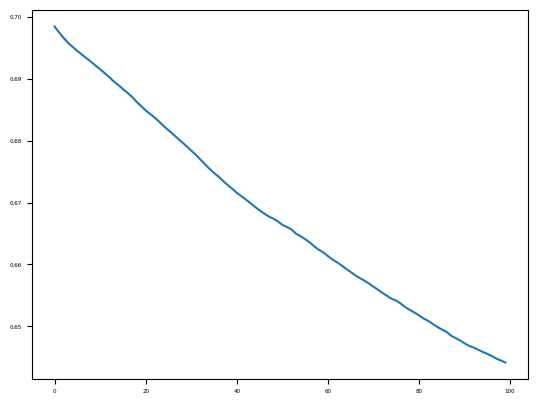

In [ ]:
n_steps = 100
con.sgd_steps = n_steps//2
losses = torch.zeros(n_steps)
sgd_weights([cppn], None, inputs, target, con.objective_functions, norm, con, record_loss=losses[:n_steps//2])
P_cx, P_nodes = cppn.prune(con)
print("pruned (cxs,nodes)", P_cx, P_nodes)
print(len(cppn.connection_genome), len(cppn.node_genome))

sgd_weights([cppn], None, inputs, target, con.objective_functions, norm, con, record_loss=losses[n_steps//2:])

plt.plot(losses)
plt.show()

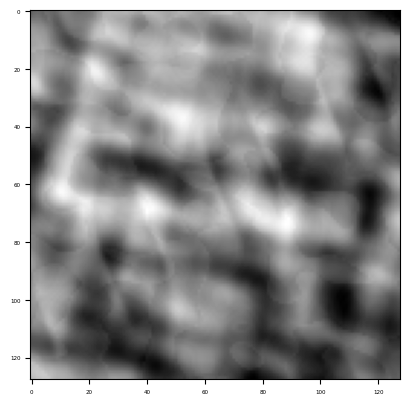

In [ ]:
img = cppn(inputs, channel_first=False).detach().cpu().numpy()
plt.imshow(img, cmap="gray")
plt.show()

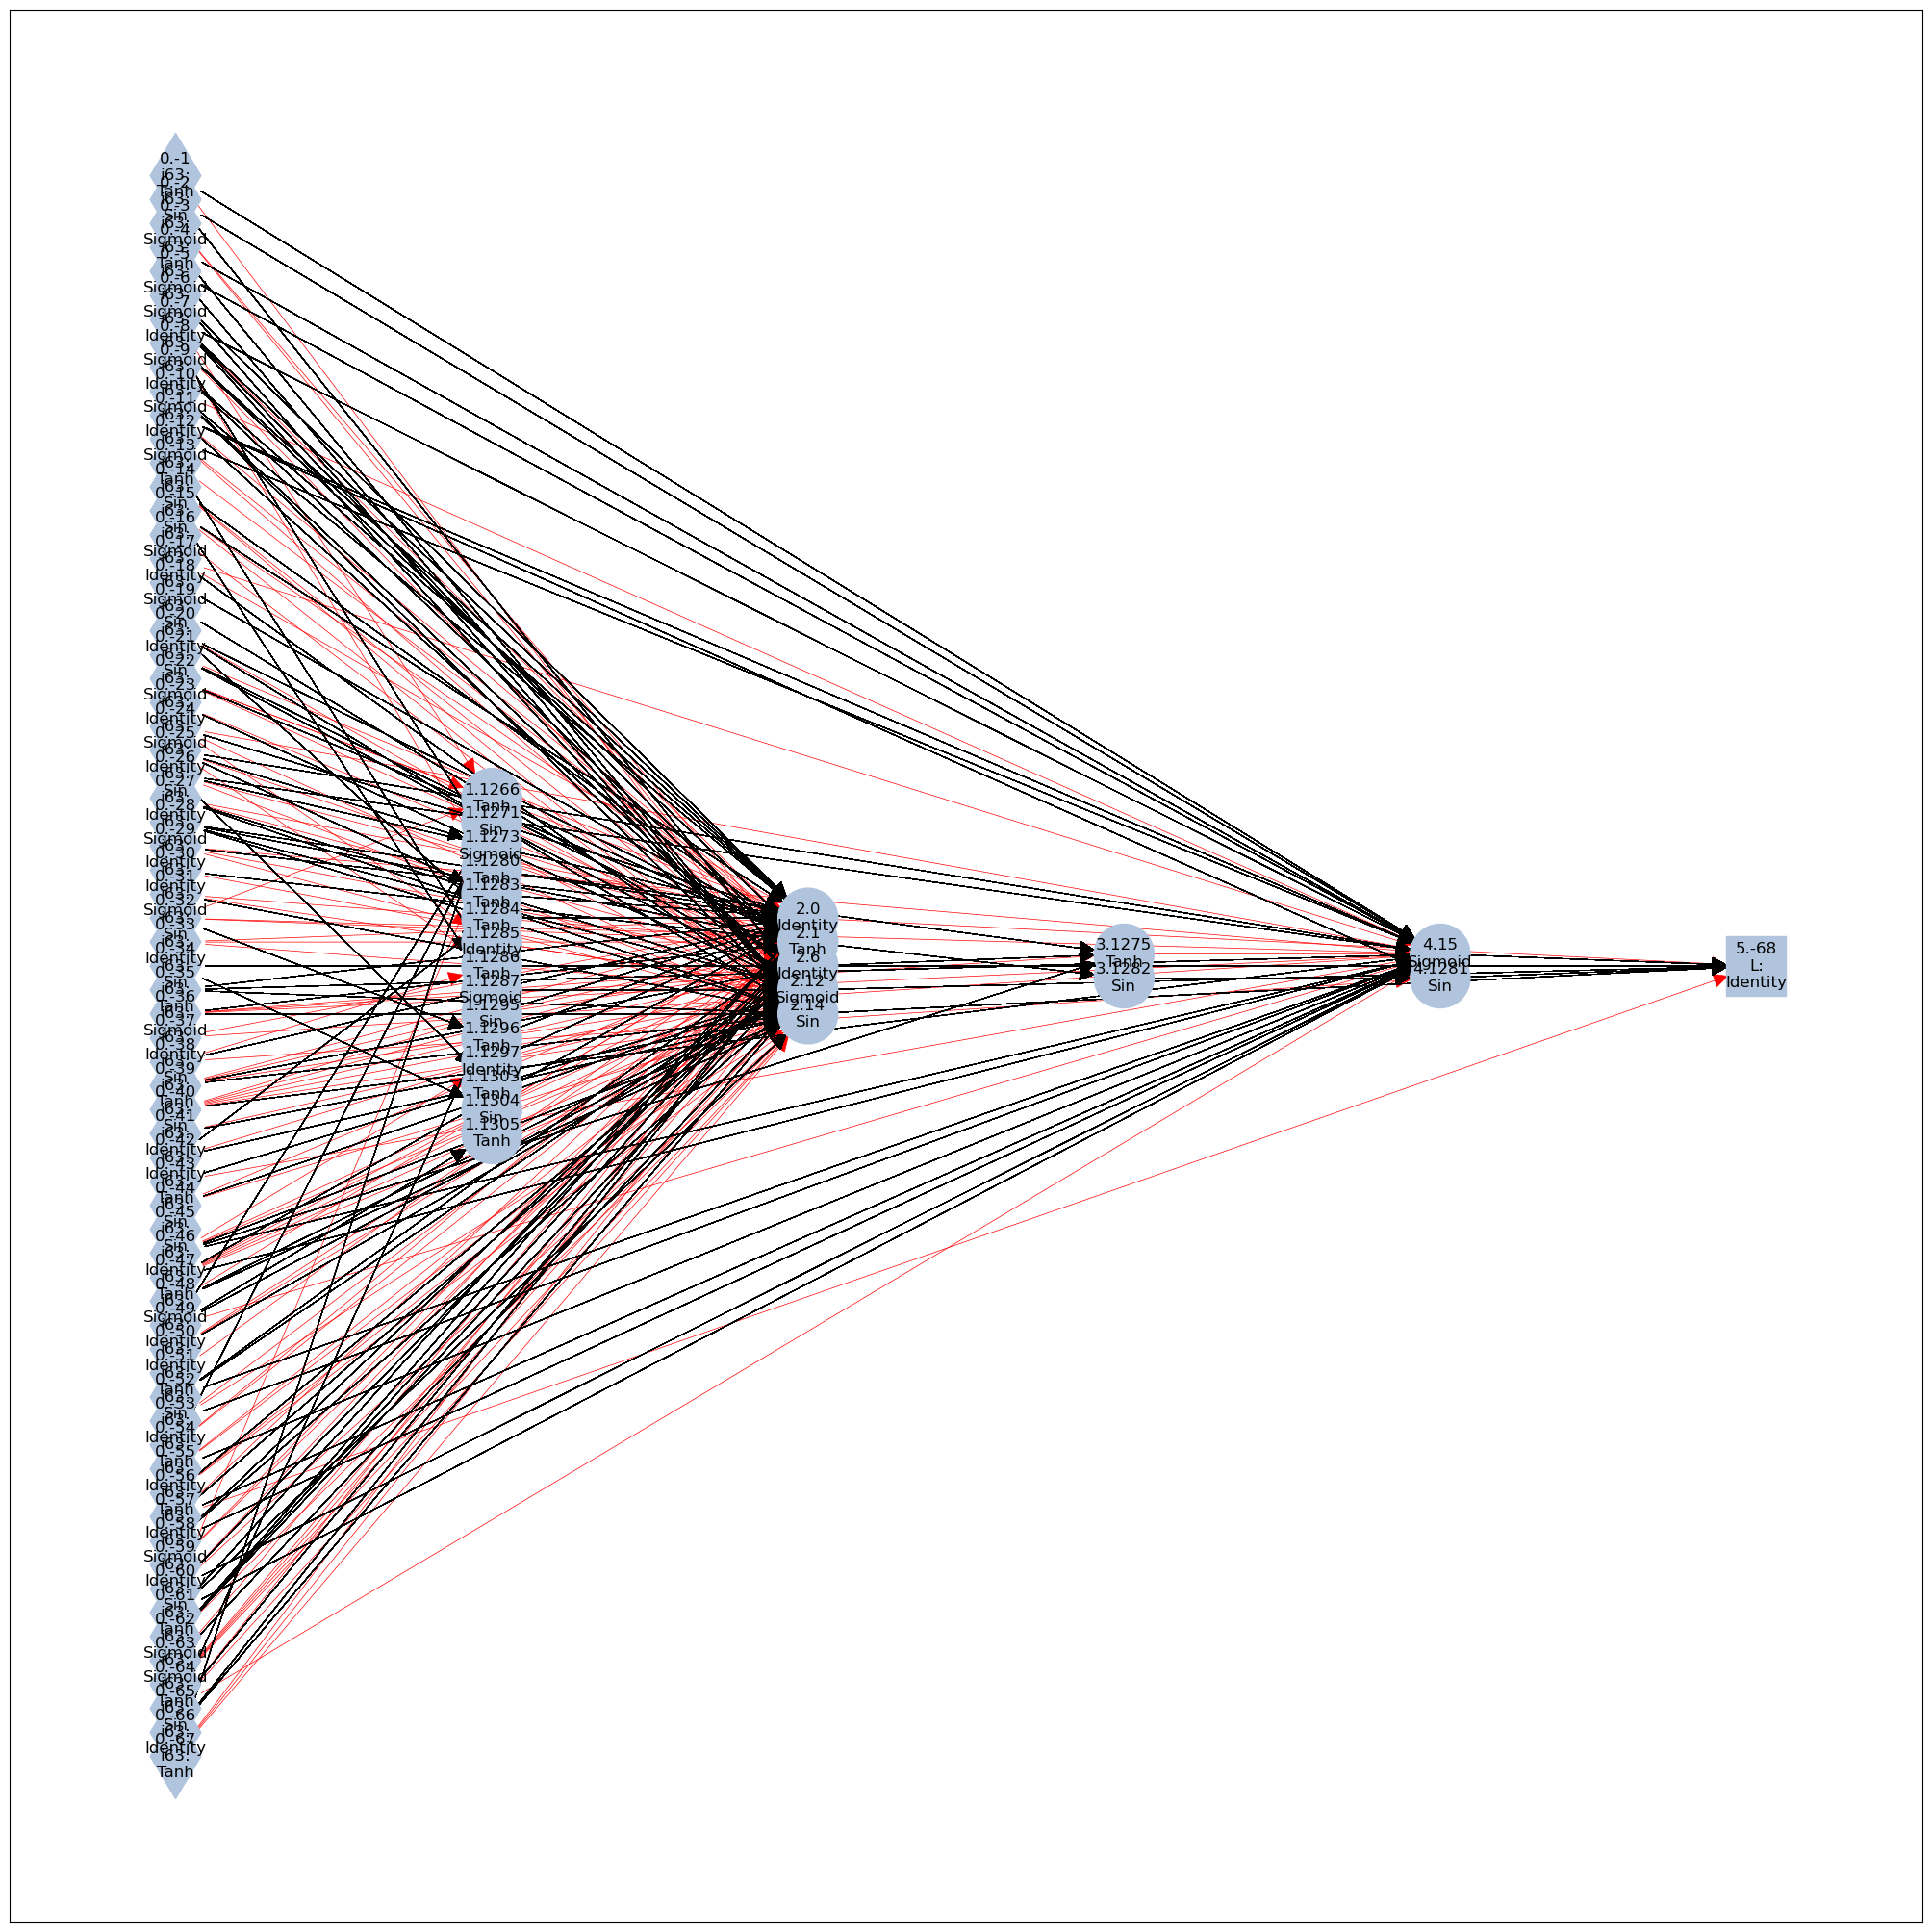

: 

In [ ]:
from cppn.visualize import visualize_network

visualize_network(cppn, config, show=True)

## Show the latest genome from a run

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
created config of type <class 'move_config.MoveConfig'>
Expecting up to 1000000 batches
Stop condition: StopAfterFwdCalls
torch.Size([525, 527, 67])
67


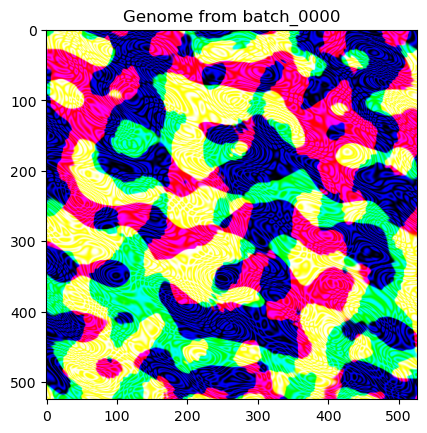

In [ ]:
%load_ext autoreload
%autoreload 2
import os
import json
from move_config import MoveConfig
from evolution import CPPNEvolutionaryAlgorithm
path = "/home/jackson/projects/move/public_github/results/test/conditions/test/run_3724434194452058606/"
genomes_path = os.path.join(path, "genomes")
import torch
inputs= None
if os.path.exists(os.path.join(path, "inputs.pt")):
    inputs = torch.load(os.path.join(path, "inputs.pt"))

last_genome = sorted(os.listdir(genomes_path))[-1]
path = os.path.join(genomes_path, last_genome)

with open(path, 'r') as f:
    genome = json.load(f)

from cppn.cppn import CPPN
cppn = CPPN.create_from_json(genome, ConfigClass=MoveConfig)

config = MoveConfig.create_from_json(genome["config"], config_type=MoveConfig)
config.fourier_seed = None

if inputs is None:
    alg = CPPNEvolutionaryAlgorithm(config)
    alg.init_inputs()

    inputs = alg.inputs

print(inputs.shape)
print(config.num_inputs)


img = cppn(inputs, channel_first=False).detach().cpu().numpy()
import matplotlib.pyplot as plt
plt.imshow(img, cmap="gray")
plt.title(f"Genome from {path.split('/')[-1].split('.')[0]}")
plt.show()

## FN_MASK DISTRIBUTION

In [68]:
import torch
import os
import seaborn as sns
import matplotlib.pyplot as plt
from move_config import MoveConfig
import pandas as pd

mask_path = os.path.join(path, "fn_mask.pt")
if not os.path.exists(mask_path):
    mask_path = os.path.join(path, "Fm_mask.pt") # old-school typo version
mask = torch.load(mask_path)

mask = mask.to("cpu")

config = MoveConfig.create_from_json(json.load(open(os.path.join(path, "config.json"))), config_type=MoveConfig)

In [69]:
def reshape_to_square(mask):
    # mask is num_fns x num_cells
    # we want to reshape it to num_fns x sqr_size x sqr_size
    sqr_size = int(mask.shape[1]**0.5)
    return mask.reshape(mask.shape[0], sqr_size, sqr_size)

In [70]:
# for i in range(10):
#     plt.imshow(reshape_to_square(mask)[i].cpu().numpy(), cmap="gray")
#     plt.title(f"fn {i}")
#     plt.show()

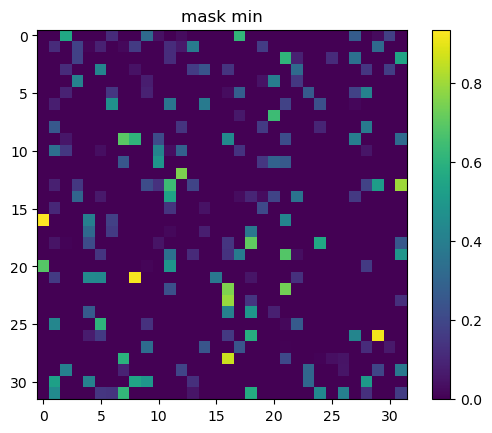

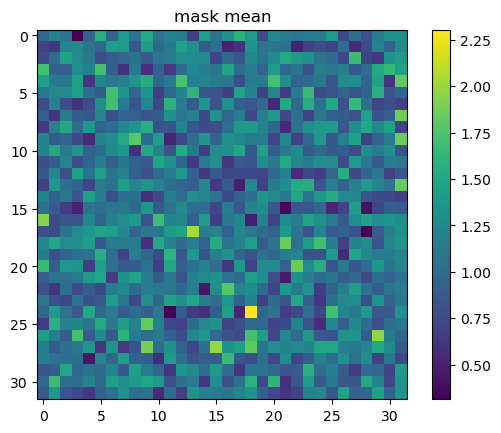

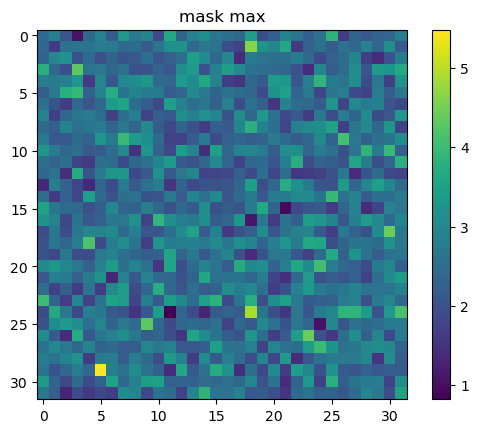

In [71]:
plt.imshow(reshape_to_square(mask).min(dim=0)[0].cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("mask min")
plt.show()

plt.imshow(reshape_to_square(mask).mean(dim=0).cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("mask mean")
plt.show()

plt.imshow(reshape_to_square(mask).max(dim=0)[0].cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("mask max")
plt.show()

/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


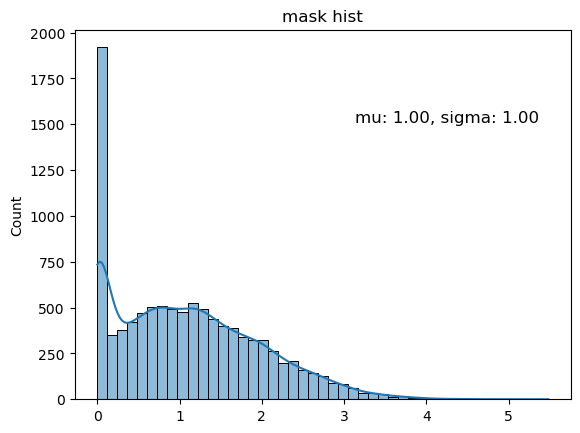

In [72]:
mu = config.soft_mask_mu
sigma = config.soft_mask_sigma
sns.histplot(mask.flatten(), kde=True)
plt.title("mask hist")
plt.text(0.75, 0.75, f"mu: {mu:.2f}, sigma: {sigma:.2f}", fontsize=12, ha='center', transform=plt.gca().transAxes)
plt.show()

/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

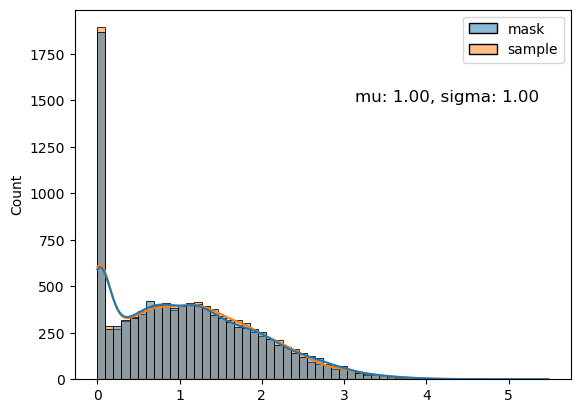

In [73]:
dst = torch.distributions.normal.Normal(mu, sigma)
sample = dst.sample((len(mask.flatten()),)).flatten()
sample = sample.clamp(0, torch.inf)
# plot the histogram of dst
plt.text(0.75, 0.75, f"mu: {mu:.2f}, sigma: {sigma:.2f}", fontsize=12, ha='center', transform=plt.gca().transAxes)


df = pd.DataFrame({"mask": mask.flatten().numpy(), "sample": sample.numpy()})

sns.histplot(df, kde=True)

plt.show()

/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/jackson/miniconda3/envs/move/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future v

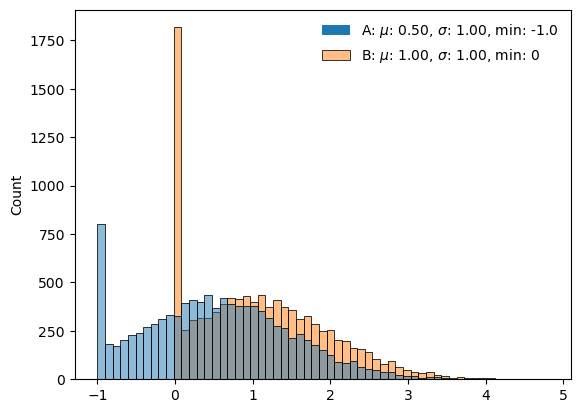

In [98]:
mu_sigma_min = [(0.5, 1.0, -1.0), (1.0, 1.0, 0)]
letters = ["A", "B"]
df = {}
for (mu, sigma, min), letter in zip(mu_sigma_min, letters):
    dst = torch.distributions.normal.Normal(mu, sigma)
    sample = dst.sample((len(mask.flatten()),)).flatten()
    if min is not None:
        sample = sample.clamp(min, torch.inf)
    df[f"{letter}: $\mu$: {mu:.2f}, $\sigma$: {sigma:.2f}, min: {min}"] = sample.numpy()

df = pd.DataFrame(df)

sns.histplot(df, kde=False)
plt.legend(df.columns, loc='upper right', frameon=False, ncol=1)

plt.show()

In [3]:
import torch, os, shutil
from MOVE.move_config import MOVEConfig
from MOVE.move import MOVE

out_dir = 'tmp_results/runtime_smoke'
if os.path.exists(out_dir):
    shutil.rmtree(out_dir)

config = MOVEConfig()
config.device = torch.device('cuda')
config.num_cells = 4
config.batch_size = 4
config.initial_batch_size = 4
config.total_offspring = 4
config.objective_functions = ['mse', 'psnr', 'gmsd']
config.allow_jumps = torch.inf
config.target = torch.rand(33, 33, 3)
config.output_dir = out_dir
config.experiment_condition = 'smoke'
config.low_mem = True
config.record_frequency_batch = 1
config.dry_run = False
config.with_grad = False
config.sgd_steps = 0
config.norm_df_path = 'data/target_fitness_fn_ranges.csv'
config.target_path = 'smoke_target'

move = MOVE(config)

# create small batch of genomes
population = [(idx, idx, move.genome_type(move.config)) for idx in range(2)]
imgs = move.activate_population([g for _, _, g in population])
fit_children, fc_normed, agg = move.measure_fitness(population, imgs)
print('fitness shapes', fit_children.shape, fc_normed.shape, agg.shape)

13962057019842826736
WARN: does not account for grad_every!=1
value 300000
batch size 4
Expecting up to 112500 batches
Stop condition: StopAfterEvals
['mse', 'psnr', 'gmsd']
WARN: less combinations than cells, filling with random repeats
Using 4 out of 1 possible combinations
Number of cells:  4
Initializing record with size torch.Size([4, 112500])
Initialized MOVE on device: cuda
Measuring fitness in 1 batches


Measuring fitness:   0%|          | 0/1 [00:00<?, ?it/s]

Population size: 4
Total offspring: 0


Measuring fitness: 100%|██████████| 1/1 [00:00<00:00,  6.93it/s]

fitness shapes torch.Size([2, 3]) torch.Size([2, 3]) torch.Size([2])
